# 1-Bit HHL track simulation toy model 64 particles 7 layers

This Jupyter notebook is compatible with Python 3.13, Qiskit v2.2, Qiskit Aer v0.17, Qiskit runtime version: 0.43 and Qiskit Runtime V2 primitives.
|||
|-|-|
|**Author:** |Alain Chancé|
|**Date:** |September 29, 2025|
|**Version:** |**1.00**|
An efficient implementation of the 1-Bit HHL track simulation toy model at the LHCb at CERN derived from the following publications:
- [Alain Chancé, A Toy Model For Reconstructing Particle Tracks at LHCb at CERN with Quantum Computing, 30 Oct. 2025, LHCb_VeLo_Toy_Model_1-Bit_HHL.pdf](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/LHCb_VeLo_Toy_Model_1-Bit_HHL.pdf).
- [Xenofon Chiotopoulos, Davide Nicotra, George Scriven, Kurt Driessens, Marcel Merk, Jochen Schütz, Jacco de Vries, Mark H.M. Winands, TrackHHL: The 1-Bit Quantum Filter for particle trajectory reconstruction, 12 Jan 2026, arXiv:2601.07766](https://doi.org/10.48550/arXiv.2601.07766)
- [Xenofon Chiotopoulos, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://indico.cern.ch/event/1338689/contributions/6010017/attachments/2951297/5188722/CHEP_ppt.pdf)
- Xenofon Chiotopoulos, Miriam Lucio Martinez, Davide Nicotra, Jacco A. de Vries, Kurt Driessens, Marcel Merk, and Mark H.M. Winands, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb, EPJ Web of Conferences 337, 01181 (2025), [https://doi.org/10.1051/epjconf/202533701181](https://doi.org/10.1051/epjconf/202533701181).
- [D. Nicotra et al., arXiv:2308.00619v2, 7 Oct 2023, A quantum algorithm for track reconstruction in the LHCb vertex detector](https://arxiv.org/pdf/2308.00619).

## Import libraries

In [1]:
import matplotlib.pyplot as plt

In [2]:
from One_Bit_HHL_Simulation import One_Bit_HHL

Qiskit version: 2.2.3
Qiskit Aer version: 0.17.2
Qiskit runtime version: 0.43.1


## Setup configuration parameters

In [3]:
config = {
    #--------------------
    # Simulation options
    #--------------------
    "dz": 20,                           # layer spacing (mm)
    "layers": 7,                        # Number of layers
    "n_particles": [16, 16, 16, 16],    # Number of particles
    "p_vertices": [(0,0,4), (0,0,6), (0,0,8), (0,0,10)],  # Primary vertices
    "do_draw": False,                   # Whether to draw the HHL circuit
    "measurement_error": 0.0,           # HIT RESOLUTION (sigma on measurement) (sigma)
    "collision_noise": 0.0,             # MULTIPLE SCATTERING (angular noise proxy)
    "ghost_rate": 1e-2,                 # Ghost (fake) track rate
    "drop_rate": 0.0,                   # Hit drop (inefficiency) rate
    "display_particles": False,         # Whether to display initial particle states
    "display_hits": False,              # Whether to display hits
    "display_ghost_hits": True,         # Whether to display ghost hits
    "display_tracks": True,             # Whether to display events and ghost tracks
    "display_clusters": False,          # Whether to display clusters found by find_tracks()
    "display_false_clusters": True,     # Whether to display clusters rejected by find_tracks()
    "do_plot_tracks": True,             # Whether to plot events and ghost tracks 
    "do_solve_scipy": False,            # Whether to solve classically using scipy.sparse.linalg.cg
    "T_classical": None,                # Threshold for discretizing classical solutions
    "T_hhl": None,                      # Threshold for discretizing 1-Bit HHL solutions - None: to be computed
    "do_spectrum": False,               # Whether to analyze the classical solution spectrum
    "do_print_counts": False,           # Whether to print raw measurement counts
    "do_print_outer_segs": False,       # Whether to print segments in modules greater than 3
    #------------------------------------------
    # Files containing token (API key) and CRN
    #------------------------------------------
    "token_file": "Token.txt",          # Token file
    "CRN_file": "CRN.txt",              # CRN file
    #-------------
    # Run options
    #-------------
    "backend_name": "AerSimulator noiseless",           # AerSimulator noiseless or Fake QPU or real IBM cloud backend name
    "job_id": None,                                     # job_id of a previously run job
    "run_on_QPU": False,                                # Whether to run the quantum circuit on the target hardware
    "nshots": 100000,                                   # Number of shots
    'opt_level': 1,                                     # Optimization level
    "poll_interval": 5,                                 # Poll interval in seconds for job monitor
    "timeout": 600,                                     # Time out in seconds for job monitor
    #-------------------------------------
    # eco2AI Tracker options
    # https://github.com/sb-ai-lab/Eco2AI
    #-------------------------------------
    "do_eco2ai": True,                                   # Whether to use the eco2AI Tracker
    "project_name": "One_Bit_HHL",                       # Project name
    "experiment_description": "HHL_64_p_7_l_found_tracks",  # Experiment description
    "eco2ai_file_name": "HHL_64_p_7_l_found_tracks.csv",    # eco2AI file name
    #---------------------------------------------------------------------------------
    # Ballpark figure (kW) for the power consumption of the IBM cloud backend
    # "The power consumption of a quantum computer is about 15-25kW"
    # https://www.capgemini.com/insights/expert-perspectives/green-quantum-computing/
    #---------------------------------------------------------------------------------
    "power_QPU": 25,                    # Ballpark figure (kW) for the power consumption of the IBM cloud backend
}

## Create an instance of the One_Bit_HHL class from the configuration dictionary

In [4]:
try:
    My_HHL = One_Bit_HHL(**config)
except Exception as e:
   print(f"Error creating 1_Bit_HHL instance: {e}")


Simulation options
layer spacing (mm), dz: 20
layers: 7
n_particles: [16, 16, 16, 16], Total number: 64
primary_vertices: [(0, 0, 4), (0, 0, 6), (0, 0, 8), (0, 0, 10)]
do_draw: False
measurement hit resolution: 0.0
multiple scattering collision noise: 0.0
ghost (fake) track rate: 0.01
hit drop (inefficiency) rate: 0.0
display_particles: False
display_hits: False
display_ghost_hits: True
display_tracks: True
display_clusters: False
display_false_clusters: True
do_plot_tracks: True
do_plot_heat_map: True
do_solve_scipy: False
T_classical: None
T_hhl: None
do_spectrum: False
do_print_counts: False
do_print_outer_segs False
resolution: 25
tol: 1e-06

Run options
Backend name: AerSimulator noiseless
Run on QPU: False
Optimization level: 1

eco2AI Tracker options
project_name: One_Bit_HHL
experiment_description: HHL_64_p_7_l_found_tracks
eco2ai_file_name: HHL_64_p_7_l_found_tracks.csv

Ballpark figure (kW) for QPU power consumption: 25

Deleted: HHL_64_p_7_l_found_tracks.csv
eco2AI tracker 

## Setup events


-------------------------------------------------------------
 All 4 ghost hits created by the function make_noisy_event()
-------------------------------------------------------------

     Hit ID       x         y         z       Theta      Module ID
       0         2.56     -5.99    120.00    -1.166          6
       0        14.59     -9.41     20.00    -0.573          1
       0         5.53      8.96     20.00     1.018          1
       0         3.54     14.12     60.00     1.325          3

--------------
 Event tracks
--------------

Track ID: 0
     Hit ID       x         y         z       Theta      Module ID
       0         1.41     -3.19     20.00    -1.156          1
       1         3.16     -7.18     40.00    -1.156          2
       2         4.92    -11.17     60.00    -1.156          3
       3         6.68    -15.15     80.00    -1.156          4
       4         8.44    -19.14    100.00    -1.156          5
       5        10.20    -23.13    120.00    -1.156   

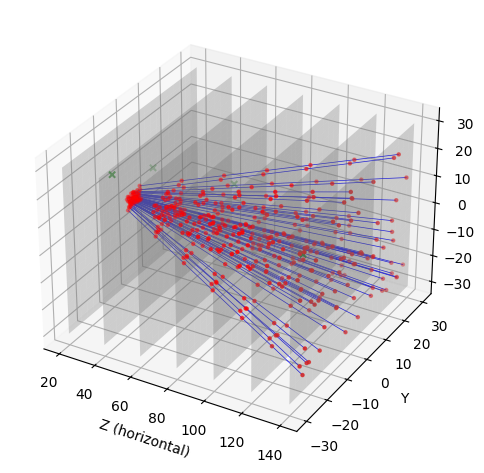


------------------------------------------------
 Polar plot of hits projected onto the XY plane
------------------------------------------------


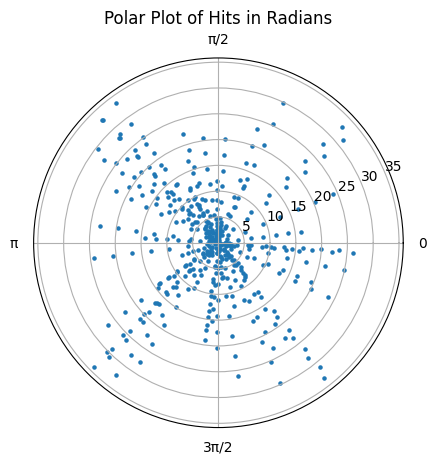

In [5]:
My_HHL.setup_events()

## Run classical and 1-Bit HHL simulations


----------------------------------------------------
 find_tracks() found 64 tracks and 4 false clusters
----------------------------------------------------

-------------------------------------------------------------
 All 4 false clusters rejected by the function find_tracks()
-------------------------------------------------------------

  Hit ID       x         y         z       Theta    Module ID
    0         2.56     -5.99    120.00    -1.166       6
    0        14.59     -9.41     20.00    -0.573       1
    0         5.53      8.96     20.00     1.018       1
    0         3.54     14.12     60.00     1.325       3

---------------------------------------------------
 All 64 tracks found by the function find_tracks()
---------------------------------------------------

Track ID: 0
     Hit ID       x         y         z       Theta      Module ID
       0         1.41     -3.19     20.00    -1.156          1
       1         3.16     -7.18     40.00    -1.156          2
  

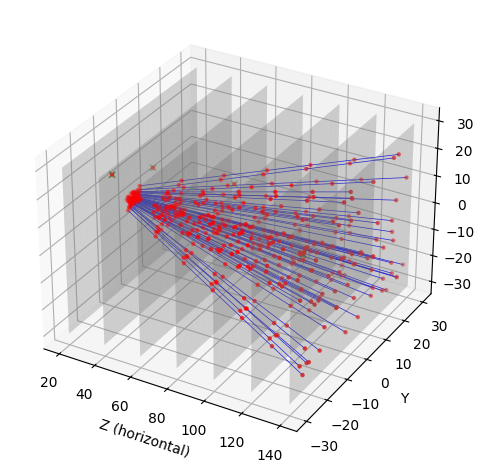


Classical processing - Duration (h): 0.0006 - Power consumption (kWh): 0.0000


In [6]:
My_HHL.run_simulation()

# References

## The Large Hadron Collider beauty (LHCb) experiment at CERN
[LHC-1] [The Large Hadron Collider beauty (LHCb) experiment](https://home.cern/science/experiments/lhcb)

[LHC-2] [LHCb Taking a closer look at LHC](https://www.lhc-closer.es/taking_a_closer_look_at_lhc/0.lhcb)

[LHC-3] [LHCb @ Syracuse: An overview](https://hep.syr.edu/quark-flavor-physics/lhcb-cern/)

[LHC-4] [LHCb Upgrade II, Detector and Physics Prospects, Vincenzo Vagnoni (INFN Bologna, CERN), for the LHCb collaboration, The 2024 International Workshop on Future Tau Charm Facilities, 15 January 2024](https://indico.pnp.ustc.edu.cn/event/91/contributions/6351/attachments/1859/3063/FTCF%2015%20January%202024.pdf)

## LHCb Velo Toy Model
[TOY-1] [OneBQF](https://github.com/Xenofon-Chiotopoulos/OneBQF/tree/main)

[TOY-2] [OneBQF.py](https://github.com/Xenofon-Chiotopoulos/OneBQF/blob/main/quantum_algorithms/OneBQF.py)

[TOY-3] [LHCb_VeLo_Toy_Model](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/tree/main)

[TOY-4] [George_Sandbox.ipynb](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/blob/main/George_Sandbox.ipynb)

[TOY-5] [Xenofon Chiotopoulos, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://indico.cern.ch/event/1338689/contributions/6010017/attachments/2951297/5188722/CHEP_ppt.pdf)

[TOY-6] [Tracking Toy Model Demo](https://github.com/Xenofon-Chiotopoulos/Tracking_Toy_model/blob/main/example_notebook.ipynb)

## Algorithms for Track Reconstruction
[ALGO-1] [Alain Chancé, A Toy Model For Reconstructing Particle Tracks at LHCb at CERN with Quantum Computing, 30 Oct. 2025, LHCb_VeLo_Toy_Model_1-Bit_HHL.pdf](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/LHCb_VeLo_Toy_Model_1-Bit_HHL.pdf)

[ALGO-2] [Xenofon Chiotopoulos, Davide Nicotra, George Scriven, Kurt Driessens, Marcel Merk, Jochen Schütz, Jacco de Vries, Mark H.M. Winands, TrackHHL: The 1-Bit Quantum Filter for particle trajectory reconstruction, 12 Jan 2026, arXiv:2601.07766](https://doi.org/10.48550/arXiv.2601.07766)

[ALGO-3] [Xenofon Chiotopoulos, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://cds.cern.ch/record/2950969/files/document.pdf)

[ALGO-4] [Xenofon Chiotopoulos, Miriam Lucio Martinez, Davide Nicotra, Jacco A. de Vries, Kurt Driessens, Marcel Merk, and Mark H.M. Winands, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb, EPJ Web of Conferences 337, 01181 (2025)](https://doi.org/10.1051/epjconf/202533701181)

[ALGO-5] [Okawa, Hideki, Quantum Algorithms for Track Reconstruction at High Energy Colliders, Workshop of Tracking in Particle Physics Experiments, May 17-19, 2024](https://indico.ihep.ac.cn/event/21775/contributions/155907/attachments/78247/97329/okawa_QTrack_20240517.pdf)

[ALGO-6] [Quantum pathways for charged track finding in high-energy collisions, Front. Artif. Intell., 30 May 2024, Sec. Big Data and AI in High Energy Physics, Volume 7 - 2024](https://www.frontiersin.org/journals/artificial-intelligence/articles/10.3389/frai.2024.1339785/full)

[ALGO-7] [D. Nicotra et al., arXiv:2308.00619v2, 7 Oct 2023, A quantum algorithm for track reconstruction in the LHCb vertex detector](https://arxiv.org/pdf/2308.00619)

[ALGO-8] [Primary Vertex Reconstruction at LHCb, LHCb-PUB-2014-044, October 21, 2014](https://cds.cern.ch/record/1756296/files/LHCb-PUB-2014-044.pdf)

[ALGO-9] [Daniel Campora, Track reconstruction made easy](https://github.com/dcampora/velopix_tracking)

## Harrow–Hassidim–Lloyd (HHL) Algorithm
[HHL-1] [V., Shwetha, Abinaya Selvarajan, Aarthi A., and Sneka R.. "Quantum Speedup for Linear Systems: An Analysis of the HHL Algorithm Using IBM Qiskit." Journal of Electronics and Informatics 6, no. 4 (2024): 317-331](https://irojournals.com/iroei/article/view/6/4/3)

[HHL-2] [Solving linear systems of equations using HHL and its Qiskit implementation, Qiskit Tutorial](https://github.com/Qiskit/textbook/blob/main/notebooks/ch-applications/hhl_tutorial.ipynb)

## Quantum Phase Estimation (QPE) Algorithm
[QPE-1] [Stefano Scali, Josh Kirsopp, Antonio Márquez Romero, Michał Krompiec, Spectral subspace extraction via incoherent quantum phase estimation, 16 Oct 2025, arXiv:2510.14744 quant-ph](https://doi.org/10.48550/arXiv.2510.14744)

[QPE-2] [Antoine Lemelin, Christophe Pere, Olivier Landon-Cardinal, Camille Coti, Mid-circuit measurement as an algorithmic primitive, 2 Sep 2025, arXiv:2506.00118 quant-ph](https://doi.org/10.48550/arXiv.2506.00118) 

[QPE-3] [Phase estimation variants and its implication for quantum/classical architecture by Microsoft, From the need to hybridize algorithmically to the need to integrate QPUs with CPUs, J. Mikael, EDF, E. Vergnaud, Teratec TQCI, Conference on QPU/CPU Integration](https://www.teratec.eu/library/seminaires/2022/TQCI/Microsoft_Hybrid_QC_EDF.pdf)

[QPE-4] [quantum-phase-estimation.ipynb, Qiskit Textbook](https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/quantum-phase-estimation.ipynb)

[QPE-5] [qiskit.circuit.library.phase_estimation](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.phase_estimation)

[QPE-6] [Non-variational and Phase Estimation algorithms, Quantinuum's InQuanto 5.1.0](https://docs.quantinuum.com/inquanto/manual/algorithms/non_variational_overview.html)

## Simulated Bifurcation Algorithm
[BIFUR-1] [Simulated Bifurcation for Python](https://github.com/bqth29/simulated-bifurcation-algorithm/tree/main)

[BIFUR-2] [Hideki Okawa, Qing-Guo Zeng, Xian-Zhe Tao, Man-Hong Yung, Quantum-Annealing-Inspired Algorithms for Track Reconstruction at High-Energy Colliders, 30 Aug 2024, 	arXiv:2402.14718 quant-ph](https://doi.org/10.48550/arXiv.2402.14718)

## Quantum Machine Learning in High Energy Physics
[QML-1] [Wen Guan et al, Quantum machine learning in high energy physics, 2021 Mach. Learn.: Sci. Technol. 2 011003](https://quantum.web.cern.ch/sites/default/files/2021-07/Quantum%20Machine%20Learning%20in%20High%20Energy%20Physics.pdf)

[QML-2] [Gray HM. Quantum pattern recognition algorithms for charged particle tracking. Philos Trans A Math Phys Eng Sci. 2022 Feb 7;380(2216):20210103. doi: 10.1098/rsta.2021.0103. Epub 2021 Dec 20. PMID: 34923843; PMCID: PMC8685607.](https://pmc.ncbi.nlm.nih.gov/articles/PMC8685607/)

## Hough transform
[HOUGH-1] [Straight line Hough transform](https://scikit-image.org/docs/stable/auto_examples/edges/plot_line_hough_transform.html)

[HOUGH-2] [Frank Klefenz, Nico Wittrock, Frank Feldhoff, Parallel Quantum Hough Transform, 15 Nov 2023, arXiv:2311.09002 eess.IV](https://doi.org/10.48550/arXiv.2311.09002)

[HOUGH-3] [F. Klefenz, K.-H. Noffz, W. Conen, R. Zoz, A. Kugel, and R. Manner. “Track recognition in 4 µs by a systolic trigger processor using a parallel Hough transform”. IEEE Transactions on Nuclear Science 40, 688–691 (1993)](https://ieeexplore.ieee.org/document/256642)

## Energetics of quantum computing

[EN-1] informatique quantique état de l’art, perspective et défis, Olivier Ezratty, SFGP, Paris, 5 novembre 2025, https://www.oezratty.net/Files/Conferences/Olivier%20Ezratty%20Informatique%20Quantique%20SFGP%20Nov2025.pdf 

[EN-2] Q2B25 Paris | Olivier Ezratty, Academic, Co Founder, Free Electron, EPITA, Quantum Energy Initiative, 
QC Ware, September 24-25 2025, https://www.youtube.com/watch?v=JVtm3pbesnA

[EN-3] Green quantum computing, Capgemini, 8 May 2023, https://www.capgemini.com/insights/expert-perspectives/green-quantum-computing/

## SQD_Alain
[SQD-1] [SQD_Alain](https://github.com/AlainChance/SQD_Alain)